## TASK 2

**Choice of dataset**: [Kaggle: Simpsons Faces](https://www.kaggle.com/datasets/kostastokis/simpsons-faces)

The dataset contains 9877 Simpsons faces, extracted from seasons 25-28. All images are 200x200 pixels, each centered on a single face.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import numpy as np


#### Part 1

In [2]:
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super(VAE, self).__init__()
        # ==========================================
        # ENCODER: Compressing 200x200 -> 5x5
        # ==========================================

        # NOTE: we don't use Max Pooling like in classical CNN and use Strided Convolutions instead
        # stride = 2 means the convolutional filter jumps 2 pixels at a time as it slides across the image
        # Max Pooling throws away data (it only keeps the highest pixel value in a grid). 
        # By using a stride of 2, the network learns its own optimal way to downsample the image.
        self.encoder = nn.Sequential(
            # LAYER 1
            # in_channels=3: We start with 3 color channels (Red, Green, Blue).
            # out_channels=32: The network applies 32 unique filters to find basic edges/colors.
            # Since we want to cut the image size in half, we need stride=2, padding=1 and kernel_size=4
            # Spatial Math: (200 - 4 + 2*1) / 2 + 1 = 100
            # Image size drops from 200x200 -> 100x100
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            
            # LAYER 2
            # Image size drops from 100x100 -> 50x50
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            
            # LAYER 3
            # Image size drops from 50x50 -> 25x25
            # NOTE: We have hit an odd number (25). A standard stride=2 will break here.
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            
            # LAYER 4
            # To fix the 25x25 problem, we use a kernel of 5 and a stride of 5, with no padding.
            # This means the filter jumps 5 pixels at a time, fitting perfectly into 25 exactly 5 times.
            # Spatial Math: (25 - 5 + 0) / 5 + 1 = 5
            # Image size drops from 25x25 -> 5x5
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=5, stride=5, padding=0),
            nn.ReLU(),
            
            # Flatten takes the 3D tensor (256 channels, 5x5 grid) and unrolls it into a 1D list.
            nn.Flatten()
        )
        
        # ==========================================
        # THE BOTTLENECK (Latent Space)
        # ==========================================
        # Flattened size: 256 channels * 5 width * 5 height = 6400
        #
        # Hardware Note: Crushing the image down to 5x5 is vital for memory management. 
        # If we stopped at 50x50, the flattened size would be 160,000.
        
        # fc_mu predicts the "center" of the probability distribution for the image.
        self.fc_mu = nn.Linear(in_features=6400, out_features=latent_dim)
        
        # fc_logvar predicts the "spread" or variance of that distribution.
        self.fc_logvar = nn.Linear(in_features=6400, out_features=latent_dim)
        
        # ==========================================
        # DECODER: Expanding 5x5 -> 200x200
        # ==========================================
        
        # First, we take the sampled latent vector and blow it back up 
        # to 6400 numbers so we can un-flatten it into our 5x5 grid.
        self.fc_dec = nn.Linear(in_features=latent_dim, out_features=6400)
        
        # The decoder is the exact inverse of the encoder. We use ConvTranspose2d, 
        # which effectively "paints" pixels outward rather than compressing them inward.
        self.decoder = nn.Sequential(
            
            # LAYER 4 (Reversed)
            # We perfectly reverse the parameters of Encoder Layer 4 (kernel=5, stride=5).
            # Image size grows from 5x5 -> 25x25
            nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=5, stride=5, padding=0),
            nn.ReLU(),
            
            # LAYER 3 (Reversed)
            # Image size grows from 25x25 -> 50x50
            nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            
            # LAYER 2 (Reversed)
            # Image size grows from 50x50 -> 100x100
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            
            # LAYER 1 (Reversed)
            # out_channels=3: The very last layer MUST output 3 channels to recreate the RGB image.
            # Image size grows from 100x100 -> 200x200
            nn.ConvTranspose2d(in_channels=32, out_channels=3, kernel_size=4, stride=2, padding=1),
            
            # Since pixel values are traditionally normalized between 0 and 1, this ensures 
            # the network doesn't generate "impossible" pixel colors.
            nn.Sigmoid() 
        )

    def reparameterize(self, mu, logvar):
        """
        The reparameterization trick allows us to backpropagate through the random sampling.
        """
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # Encode
        x_enc = self.encoder(x)
        
        # Get latent parameters
        mu = self.fc_mu(x_enc)
        logvar = self.fc_logvar(x_enc)
        
        # Sample from latent space
        z = self.reparameterize(mu, logvar)
        
        # Decode
        x_dec = self.fc_dec(z)
        x_dec = x_dec.view(-1, 256, 5, 5) # Unflatten back to feature maps
        reconstruction = self.decoder(x_dec)
        
        return reconstruction, mu, logvar

def vae_loss(reconstruction, original, mu, logvar):
    """
    VAE Loss = Reconstruction Loss + Kullback-Leibler Divergence
    """
    # Measure how well the image was reconstructed (MSE or BCE)
    recon_loss = F.mse_loss(reconstruction, original, reduction='sum')
    
    # Measure how closely the latent space matches a standard normal distribution
    kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    total_loss = recon_loss + kld_loss

    return total_loss, recon_loss, kld_loss

In [6]:
# HYPERPARAMETERS
BATCH_SIZE = 64
EPOCHS = 50
LEARNING_RATE = 1e-4
LATENT_DIM = 128

In [7]:
DEVICE = torch.device('cuda:2' if torch.cuda.is_available() else 'cpu')
print(f"Device used: {DEVICE}")

Device used: cuda:2


In [8]:
# Define transformations specific to our architecture
transform = transforms.Compose([
    transforms.Resize((200, 200)), # Ensure all images are 200x200
    transforms.ToTensor() # Go from (200, 200, 3) to (3, 200, 200) and convert to [0, 1] scale by dividing all pixel values by 255.0
])

In [9]:
# Load Dataset
dataset = datasets.ImageFolder(root="./simpsons", transform=transform)

# Train/Val split
total_size = len(dataset)
val_size = int(0.2 * total_size)
train_size = total_size - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create Dataloaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [10]:
# model_vae initialization
model_vae = VAE(latent_dim=LATENT_DIM).to(DEVICE)
optimizer_vae = optim.Adam(model_vae.parameters(), lr=LEARNING_RATE)

history_vae = {
    'train_loss': [], 'val_loss': [], 
    'train_recon': [], 'train_kl': []
}

In [11]:
print("Starting Training/Validation")

for epoch in range(EPOCHS):
    model_vae.train()
    train_loss_sum = 0
    train_recon_sum = 0
    train_kl_sum = 0

    # =========================
    # TRAINING PHASE
    # =========================
    for images, _ in train_loader:
        images = images.to(DEVICE)
        optimizer_vae.zero_grad()
        
        reconstruction, mu, logvar = model_vae(images)
        loss, recon, kl = vae_loss(reconstruction, images, mu, logvar)
        
        loss.backward()
        optimizer_vae.step()
        
        train_loss_sum += loss.item()
        train_recon_sum += recon.item()
        train_kl_sum += kl.item()

    # =========================
    # VALIDATION PHASE
    # =========================
    model_vae.eval()
    val_loss_sum = 0
    
    with torch.no_grad():
        for val_images, _ in val_loader:
            val_images = val_images.to(DEVICE)
            reconstruction, mu, logvar = model_vae(val_images)
            loss, _, _ = vae_loss(reconstruction, val_images, mu, logvar)
            val_loss_sum += loss.item()
            
    # Calculate averages for the epoch
    avg_train_loss = train_loss_sum / len(train_loader.dataset)
    avg_train_recon = train_recon_sum / len(train_loader.dataset)
    avg_train_kl = train_kl_sum / len(train_loader.dataset)
    avg_val_loss = val_loss_sum / len(val_loader.dataset)
    
    # Save to history_vae
    history_vae['train_loss'].append(avg_train_loss)
    history_vae['train_recon'].append(avg_train_recon)
    history_vae['train_kl'].append(avg_train_kl)
    history_vae['val_loss'].append(avg_val_loss)
    
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Starting Training/Validation
Epoch 1 | Train Loss: 8402.2549 | Val Loss: 6789.1900
Epoch 2 | Train Loss: 6500.9465 | Val Loss: 6341.1401
Epoch 3 | Train Loss: 6107.2693 | Val Loss: 5734.6251
Epoch 4 | Train Loss: 4977.0404 | Val Loss: 4290.4008
Epoch 5 | Train Loss: 3980.7301 | Val Loss: 3858.3438
Epoch 6 | Train Loss: 3698.5648 | Val Loss: 3652.9472
Epoch 7 | Train Loss: 3549.2425 | Val Loss: 3564.7599
Epoch 8 | Train Loss: 3448.5128 | Val Loss: 3446.6498
Epoch 9 | Train Loss: 3366.8754 | Val Loss: 3399.5618
Epoch 10 | Train Loss: 3297.3392 | Val Loss: 3327.1120
Epoch 11 | Train Loss: 3242.8567 | Val Loss: 3266.9708
Epoch 12 | Train Loss: 3189.3399 | Val Loss: 3238.5168
Epoch 13 | Train Loss: 3143.8526 | Val Loss: 3165.4310
Epoch 14 | Train Loss: 3097.8918 | Val Loss: 3153.2094
Epoch 15 | Train Loss: 3057.4057 | Val Loss: 3097.1089
Epoch 16 | Train Loss: 3018.2832 | Val Loss: 3068.0567
Epoch 17 | Train Loss: 2984.4748 | Val Loss: 3023.2282
Epoch 18 | Train Loss: 2952.8573 | Val Loss: 

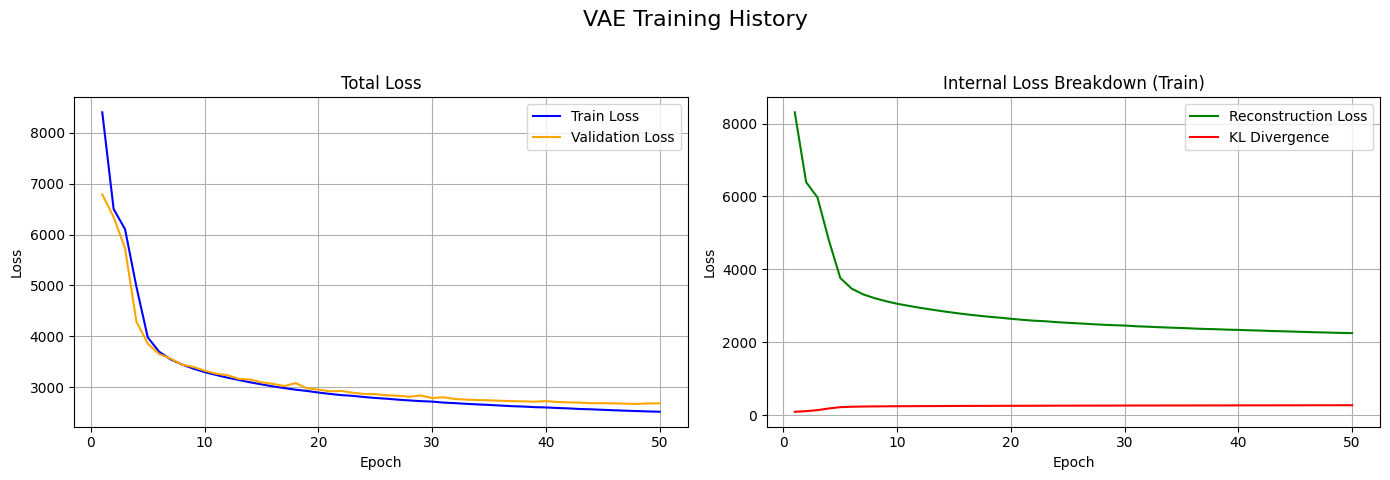

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("VAE Training History", fontsize=16)

# Plot 1: Training vs Validation Total Loss
axs[0].plot(range(1, EPOCHS+1), history_vae['train_loss'], label='Train Loss', color='blue')
axs[0].plot(range(1, EPOCHS+1), history_vae['val_loss'], label='Validation Loss', color='orange')
axs[0].set_title('Total Loss')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].legend()
axs[0].grid(True)

# Plot 2: VAE Internal Breakdown (Recon vs KL)
axs[1].plot(range(1, EPOCHS+1), history_vae['train_recon'], label='Reconstruction Loss', color='green')
axs[1].plot(range(1, EPOCHS+1), history_vae['train_kl'], label='KL Divergence', color='red')
axs[1].set_title('Internal Loss Breakdown (Train)')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Loss')
axs[1].legend()
axs[1].grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

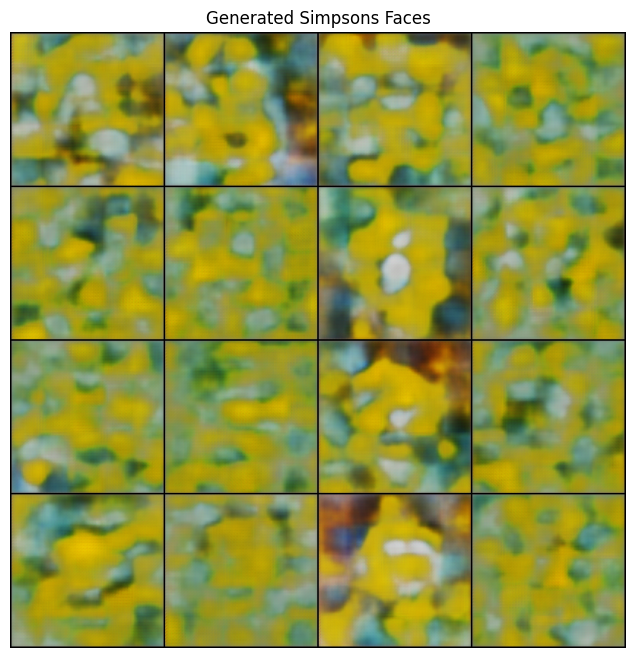

In [13]:
# Generate 16 images
num_images = 16
model_vae.eval()

with torch.no_grad():
    # Sample random noise from a standard normal distribution
    # Shape: [num_images, latent_dim]
    random_latent_vectors = torch.randn(num_images, LATENT_DIM).to(DEVICE)
    
    # Pass the noise through the decoder's linear layer
    x_dec = model_vae.fc_dec(random_latent_vectors)
    
    # Reshape to match the expected 256 channels of 5x5 grids
    x_dec = x_dec.view(-1, 256, 5, 5)
    
    # Decode into images
    generated_images = model_vae.decoder(x_dec)
    
# Move images to CPU for plotting
generated_images = generated_images.cpu()

# Create a grid of images
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Generated Simpsons Faces")

# vutils.make_grid automatically handles the padding and arranging
grid = vutils.make_grid(generated_images, nrow=4, padding=2, normalize=False)

# PyTorch uses (Channels, Height, Width) but matplotlib needs (Height, Width, Channels)
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
plt.show()

#### Results Analysis

* Training and Validation loss both dropped smoothly and stayed perfectly aligned. There is no sign of overfitting.
* Reconstruction Loss plummeted while KL Divergence slightly rose. This is the ideal "tug-of-war". 
* The generated images remain blurry because VAEs are mathematically biased toward blurriness. 

To get better images, we must transition to a GAN, where a Discriminator will actively penalize blurry outputs. 

#### Part 2

To build a GAN, we are using 2 opposing models:

A Generator: This is just the VAE's Decoder. It takes random noise and tries to paint a realistic Simpsons face.

The Discriminator: This is similar to the VAE's Encoder, but instead of compressing the image, its only job is to look at a face and output a single probability: Is this real (1.0) or fake (0.0)?

In [19]:
class Generator(nn.Module):
    def __init__(self, latent_dim=128):
        super(Generator, self).__init__()
        
        # Take the random noise and expand it to our 256 features * 5x5 starting grid
        self.fc = nn.Linear(latent_dim, 6400)
        
        self.model = nn.Sequential(
            # Layer 1: 5x5 -> 25x25
            nn.ConvTranspose2d(256, 128, kernel_size=5, stride=5, padding=0),
            nn.BatchNorm2d(128), # Normalizes the layer to keep gradients stable
            nn.ReLU(True),
            
            # Layer 2: 25x25 -> 50x50
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            
            # Layer 3: 50x50 -> 100x100
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            
            # Layer 4: 100x100 -> 200x200
            nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid() # Outputs pixel values between 0 and 1
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 256, 5, 5) # Unflatten into feature maps
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        
        self.model = nn.Sequential(
            # Layer 1: 200x200 -> 100x100
            nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True), # LeakyReLU is standard for GAN Discriminators
            
            # Layer 2: 100x100 -> 50x50
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),
            
            # Layer 3: 50x50 -> 25x25
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3),

            # Layer 4: 25x25 -> 5x5
            nn.Conv2d(128, 256, kernel_size=5, stride=5, padding=0),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Final Classification Layer
            nn.Flatten(),
            nn.Linear(6400, 1), # Outputs a single number
            nn.Sigmoid()        # Squashes that number into a probability (0.0 to 1.0)
        )

    def forward(self, x):
        return self.model(x)

In [20]:
generator = Generator(LATENT_DIM).to(DEVICE)
discriminator = Discriminator().to(DEVICE)
# Binary Cross Entropy (True/False loss)
criterion = nn.BCELoss()
# We need TWO separate optimizers so they can fight each other.
# A learning rate of 0.0002 and beta1 of 0.5 and beta2 of 0.999 is an industry standard
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))


In [21]:
print("Starting Training")


history = {'d_loss': [], 'g_loss': []}

for epoch in range(EPOCHS):
    d_loss_sum = 0
    g_loss_sum = 0
    
    for i, (real_images, _) in enumerate(train_loader):
        real_images = real_images.to(DEVICE)
        batch_size = real_images.size(0)
        
        # Create our labels: Reals are 1s, Fakes are 0s
        # BUT, Tell the Discriminator that real images are only 90% real, this is called Label smoothing
        # so that the discriminator doesn't win too early.
        real_labels = torch.full((batch_size, 1), 0.9).to(DEVICE)
        fake_labels = torch.zeros(batch_size, 1).to(DEVICE)
        
        # PHASE 1: Train Discriminator (Maximize detective accuracy)
        optimizer_D.zero_grad()
        
        # Test D on REAL images
        outputs_real = discriminator(real_images)
        d_loss_real = criterion(outputs_real, real_labels)
        
        # Test D on FAKE images
        noise = torch.randn(batch_size, LATENT_DIM).to(DEVICE)
        fake_images = generator(noise)
        # Use .detach() so we don't accidentally update the Generator yet
        outputs_fake = discriminator(fake_images.detach()) 
        d_loss_fake = criterion(outputs_fake, fake_labels)
        
        # Update Discriminator weights
        d_loss = d_loss_real + d_loss_fake
        d_loss.backward()
        optimizer_D.step()
        
        # PHASE 2: Train Generator (Maximize trickery)
        optimizer_G.zero_grad()
        
        # Force the Discriminator to look at the fake images again.
        outputs_trick = discriminator(fake_images)
        
        # Tell the Generator to still aim for a perfect 1.0 to maximize its effort
        target_labels = torch.ones(batch_size, 1).to(DEVICE)
        g_loss = criterion(outputs_trick, target_labels)
        
        # Update Generator weights
        g_loss.backward()
        optimizer_G.step()
        
        # Track losses
        d_loss_sum += d_loss.item()
        g_loss_sum += g_loss.item()
        
    # Calculate epoch averages
    avg_d_loss = d_loss_sum / len(train_loader)
    avg_g_loss = g_loss_sum / len(train_loader)
    history['d_loss'].append(avg_d_loss)
    history['g_loss'].append(avg_g_loss)
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | D Loss: {avg_d_loss:.4f} | G Loss: {avg_g_loss:.4f}")

Starting Training
Epoch [1/50] | D Loss: 0.4959 | G Loss: 4.3707
Epoch [2/50] | D Loss: 0.7314 | G Loss: 2.8526
Epoch [3/50] | D Loss: 0.7139 | G Loss: 2.6991
Epoch [4/50] | D Loss: 0.7143 | G Loss: 2.7576
Epoch [5/50] | D Loss: 0.7325 | G Loss: 2.4931
Epoch [6/50] | D Loss: 0.7165 | G Loss: 2.4900
Epoch [7/50] | D Loss: 0.7314 | G Loss: 2.6556
Epoch [8/50] | D Loss: 0.6732 | G Loss: 2.7702
Epoch [9/50] | D Loss: 0.6095 | G Loss: 2.8919
Epoch [10/50] | D Loss: 0.6119 | G Loss: 3.1398
Epoch [11/50] | D Loss: 0.5351 | G Loss: 3.2694
Epoch [12/50] | D Loss: 0.5558 | G Loss: 3.4209
Epoch [13/50] | D Loss: 0.5627 | G Loss: 3.4566
Epoch [14/50] | D Loss: 0.4919 | G Loss: 3.4817
Epoch [15/50] | D Loss: 0.4970 | G Loss: 3.5956
Epoch [16/50] | D Loss: 0.5823 | G Loss: 3.5316
Epoch [17/50] | D Loss: 0.4871 | G Loss: 3.6924
Epoch [18/50] | D Loss: 0.5080 | G Loss: 3.8195
Epoch [19/50] | D Loss: 0.4565 | G Loss: 3.7043
Epoch [20/50] | D Loss: 0.5033 | G Loss: 3.8405
Epoch [21/50] | D Loss: 0.4539 

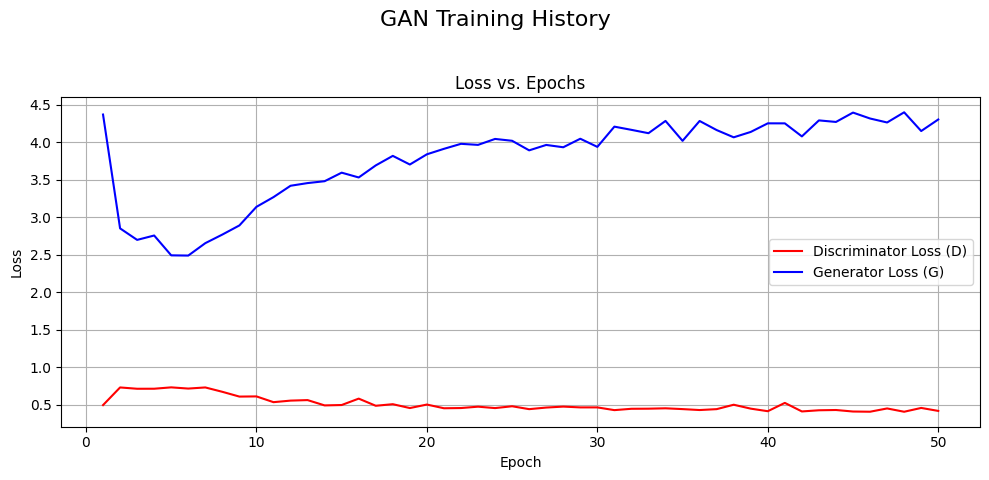

In [22]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("GAN Training History", fontsize=16)

# Plot D Loss
ax.plot(range(1, EPOCHS + 1), history['d_loss'], label='Discriminator Loss (D)', color='red')

# Plot G Loss
ax.plot(range(1, EPOCHS + 1), history['g_loss'], label='Generator Loss (G)', color='blue')


ax.set_title('Loss vs. Epochs')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.legend()
ax.grid(True)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

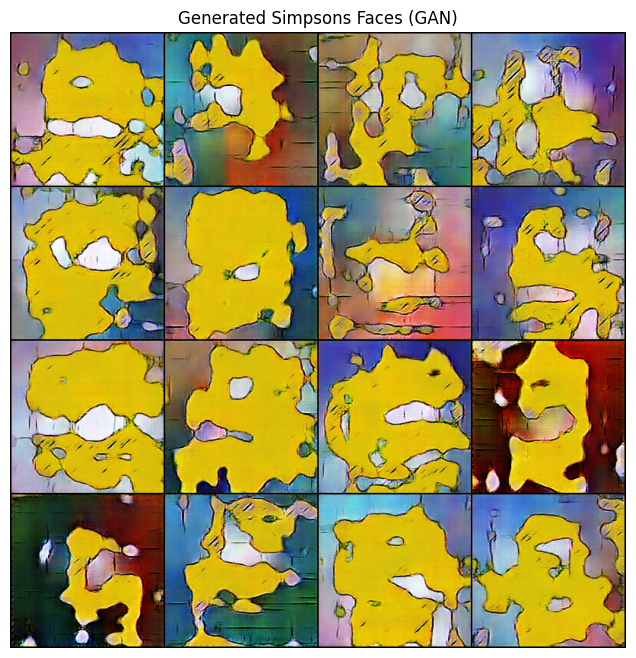

In [23]:
# Generate images
num_images = 16
generator.eval()
    
with torch.no_grad():
    # Sample random noise from a standard normal distribution
    # Shape: [num_images, latent_dim]
    random_noise = torch.randn(num_images, LATENT_DIM).to(DEVICE)
    
    # Generate images from noise using the established pipeline
    # Noise -> fc (6400) -> view (256, 5, 5) -> decoder convolutions -> 200x200 RGB
    generated_images = generator(random_noise)
    
# Move images to CPU for plotting
generated_images = generated_images.cpu()
plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Generated Simpsons Faces (GAN)")
grid = vutils.make_grid(generated_images, nrow=4, padding=2, normalize=False)
np_grid = np.transpose(grid.numpy(), (1, 2, 0))
plt.imshow(np_grid)
plt.show()

The GAN was able to learn the texture and color palette of The Simpsons, but it failed to learn correctly the geometry. Additionally, the loss curves indicate that the Discriminator is dominating the training process right from the start; its loss remains comfortably low around 0.5, while the Generator's loss steadily climbs as it struggles to keep up. (ideally they would both stabilize around ln(0.5)).

The network is probably not deep enough (or 50 epochs isn't enough) to learn exactly where those eyes and lines are supposed to go.